In [2]:
import pandas as pd

df = pd.read_csv("../data/inaug_speeches.csv", encoding="ISO-8859-1")
df.head()

,Unnamed: 0,Name,Inaugural Address,Date,text
0,4,George Washington,First Inaugural Address,"Thursday, April 30, 1789",Fellow-Citizens of the Senate and o...
1,5,George Washington,Second Inaugural Address,"Monday, March 4, 1793",Fellow Citizens: I AM again cal...
2,6,John Adams,Inaugural Address,"Saturday, March 4, 1797","WHEN it was first perceived, in ..."
3,7,Thomas Jefferson,First Inaugural Address,"Wednesday, March 4, 1801",Friends and Fellow-Citizens: CA...
4,8,Thomas Jefferson,Second Inaugural Address,"Monday, March 4, 1805","PROCEEDING, fellow-citizens, to ..."


In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         58 non-null     int64
 1   Name               58 non-null     str  
 2   Inaugural Address  58 non-null     str  
 3   Date               58 non-null     str  
 4   text               58 non-null     str  
dtypes: int64(1), str(4)
memory usage: 2.4 KB


Unnamed: 0           0
Name                 0
Inaugural Address    0
Date                 0
text                 0
dtype: int64

In [4]:
df.columns

Index(['Unnamed: 0', 'Name', 'Inaugural Address', 'Date', 'text'], dtype='str')

In [5]:
df.head()
# Nettoyage des données

,Unnamed: 0,Name,Inaugural Address,Date,text
0,4,George Washington,First Inaugural Address,"Thursday, April 30, 1789",Fellow-Citizens of the Senate and o...
1,5,George Washington,Second Inaugural Address,"Monday, March 4, 1793",Fellow Citizens: I AM again cal...
2,6,John Adams,Inaugural Address,"Saturday, March 4, 1797","WHEN it was first perceived, in ..."
3,7,Thomas Jefferson,First Inaugural Address,"Wednesday, March 4, 1801",Friends and Fellow-Citizens: CA...
4,8,Thomas Jefferson,Second Inaugural Address,"Monday, March 4, 1805","PROCEEDING, fellow-citizens, to ..."


# Nettoyage des données

In [6]:
# Nettoyage des données

import re
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# supprimer les valeurs manquantes
df = df.dropna()

# nettoyage du texte
df["clean_text"] = df["text"].apply(clean_text)

# tokenisation
df["tokens"] = df["clean_text"].apply(
    lambda x: [word for word in word_tokenize(x) if word not in stop_words]
)

df.head()
# Nettoyage des données

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yasmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yasmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yasmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Unnamed: 0,Name,Inaugural Address,Date,text,clean_text,tokens
0,4,George Washington,First Inaugural Address,"Thursday, April 30, 1789",Fellow-Citizens of the Senate and o...,fellowcitizens of the senate and of the house ...,"[fellowcitizens, senate, house, representative..."
1,5,George Washington,Second Inaugural Address,"Monday, March 4, 1793",Fellow Citizens: I AM again cal...,fellow citizens i am again called upon by the ...,"[fellow, citizens, called, upon, voice, countr..."
2,6,John Adams,Inaugural Address,"Saturday, March 4, 1797","WHEN it was first perceived, in ...",when it was first perceived in early times tha...,"[first, perceived, early, times, middle, cours..."
3,7,Thomas Jefferson,First Inaugural Address,"Wednesday, March 4, 1801",Friends and Fellow-Citizens: CA...,friends and fellowcitizens called upon to unde...,"[friends, fellowcitizens, called, upon, undert..."
4,8,Thomas Jefferson,Second Inaugural Address,"Monday, March 4, 1805","PROCEEDING, fellow-citizens, to ...",proceeding fellowcitizens to that qualificatio...,"[proceeding, fellowcitizens, qualification, co..."


In [7]:
import sys

!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 8.4 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.8 MB 10.2 MB/s eta 0:00:01
     ----------------- ---------------------- 5.5/12.8 MB 10.2 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 10.9 MB/s eta 0:00:01
     ------------------------------- ------- 10.2/12.8 MB 11.0 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 11.0 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 10.8 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


Lemmatisation

In [8]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]

df["lemmas"] = df["clean_text"].apply(lemmatize_text)
df["lemma_text"] = df["lemmas"].apply(lambda x: " ".join(x))

POS

In [9]:
def get_pos_counts(text):
    doc = nlp(text)
    return pd.Series([token.pos_ for token in doc]).value_counts().to_dict()

df["pos_counts"] = df["clean_text"].apply(get_pos_counts)

NER

In [10]:
def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df["entities"] = df["clean_text"].apply(get_entities)

Analyse de sentiment

In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["clean_text"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df["sentiment_label"] = df["sentiment_score"].apply(
    lambda x: "positive" if x > 0.05 else "negative" if x < -0.05 else "neutral"
)

Occurrence des mots

In [12]:
from collections import Counter

all_words = " ".join(df["lemma_text"]).split()
word_freq = Counter(all_words)

freq_df = pd.DataFrame(word_freq.items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False)

freq_df.head(20)

,word,frequency
142,government,620
139,people,616
129,nation,495
9,great,432
21,country,337
232,power,334
286,world,330
221,shall,314
556,state,291
49,time,265


TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)

tfidf_matrix = vectorizer.fit_transform(df["lemma_text"])
tfidf_words = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_words
)

tfidf_df.head()

,abandon,ability,able,abroad,abuse,accept,accomplish,accord,achieve,achievement,...,wish,witness,woman,word,work,world,write,wrong,year,young
0,0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.042864,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.022951,0.000000,0.000000,0.000000,0.0
1,0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.185662,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.030908,0.0,0.000000,0.02624,0.029148,0.0,0.000000,0.029148,0.0,0.0,...,0.067144,0.000000,0.0,0.000000,0.000000,0.040172,0.000000,0.000000,0.075492,0.0
3,0.041993,0.0,0.000000,0.03565,0.079202,0.0,0.000000,0.039601,0.0,0.0,...,0.030408,0.000000,0.0,0.000000,0.021240,0.054579,0.037509,0.062127,0.000000,0.0
4,0.000000,0.0,0.031432,0.00000,0.062864,0.0,0.000000,0.031432,0.0,0.0,...,0.024136,0.091728,0.0,0.024656,0.016859,0.028880,0.029772,0.000000,0.065127,0.0


Sentiment au fil du temps

In [16]:
import sys

!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [19]:
df["year"] = df["Date"].str.extract(r'(\d{4})').astype(int)

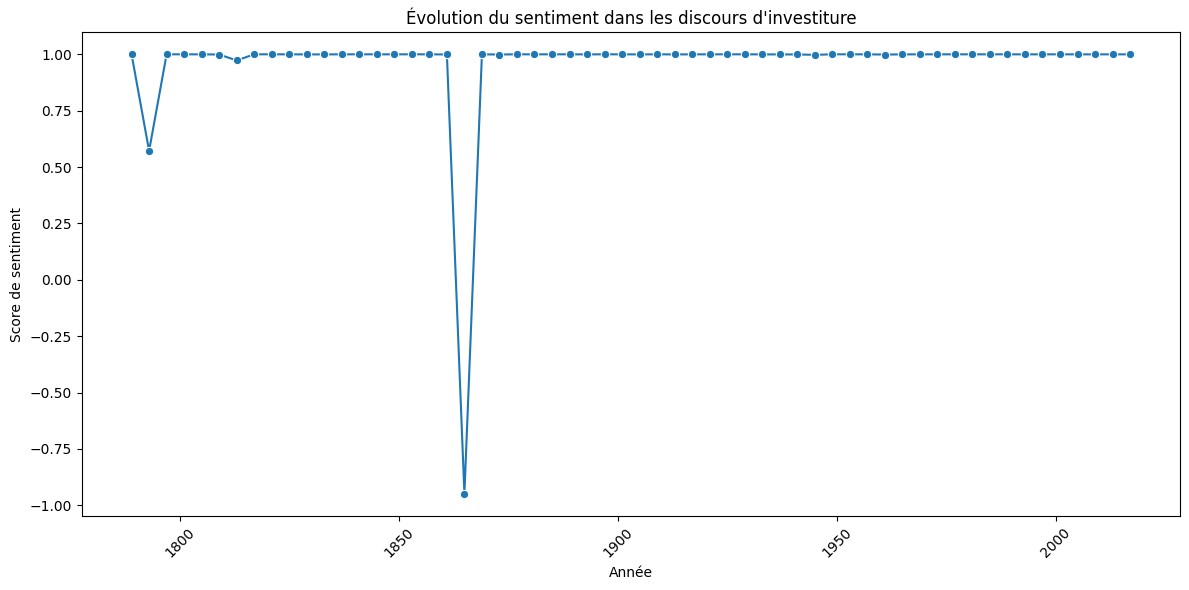

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="year", y="sentiment_score", marker="o")
plt.title("Évolution du sentiment dans les discours d'investiture")
plt.xlabel("Année")
plt.ylabel("Score de sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/sentiment_over_time.png")
plt.show()

Barplot des mots fréquents

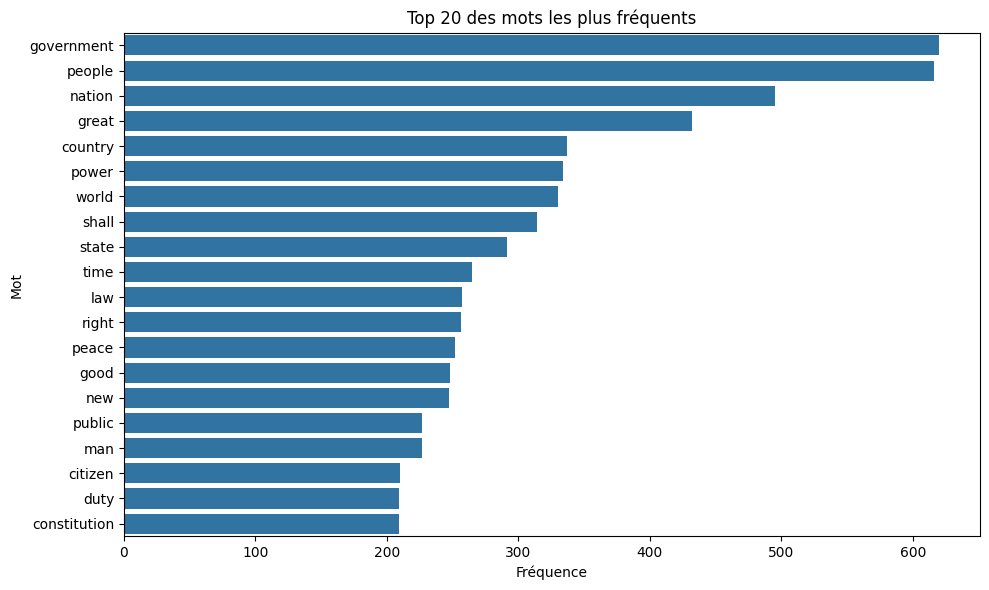

In [21]:
top_words = freq_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top_words, x="frequency", y="word")
plt.title("Top 20 des mots les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.tight_layout()
plt.savefig("../visuals/top_words.png")
plt.show()

Nuage de mots

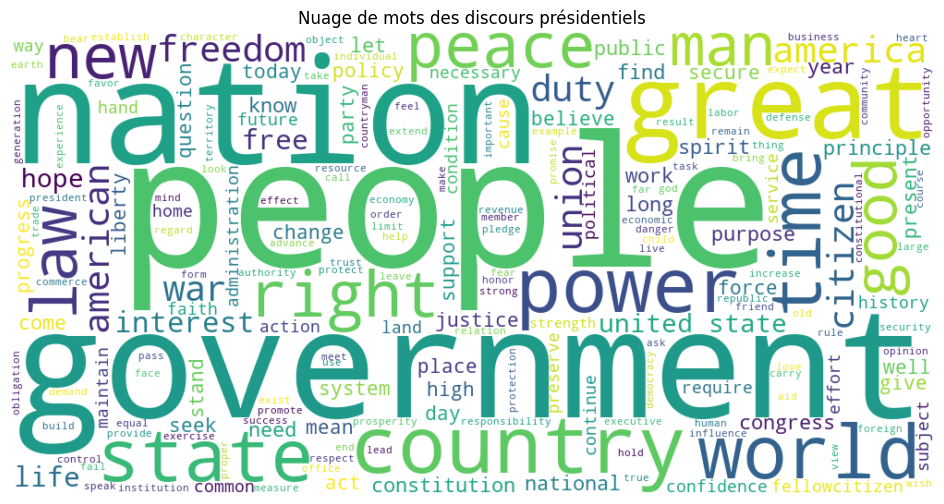

In [22]:
from wordcloud import WordCloud

text = " ".join(df["lemma_text"])

wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots des discours présidentiels")
plt.savefig("../visuals/wordcloud.png")
plt.show()

Barplot TF-IDF

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer(max_features=1000)

tfidf_matrix = vectorizer.fit_transform(df["lemma_text"])

tfidf_words = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_words
)

mean_tfidf = tfidf_df.mean().sort_values(ascending=False).head(20)

mean_tfidf

people        0.124647
government    0.121755
nation        0.109646
great         0.083194
shall         0.079880
world         0.074758
country       0.070583
power         0.068203
america       0.067290
state         0.065878
public        0.062564
peace         0.062429
new           0.058998
good          0.058322
time          0.056768
law           0.055157
man           0.054634
freedom       0.054208
union         0.054201
right         0.053503
dtype: float64

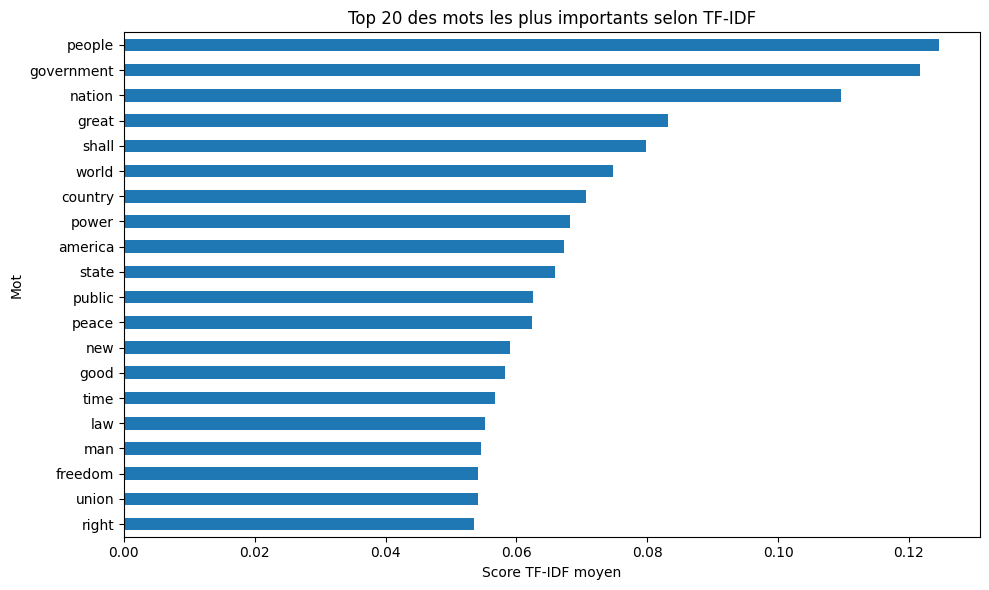

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

mean_tfidf.sort_values().plot(kind="barh")

plt.title("Top 20 des mots les plus importants selon TF-IDF")
plt.xlabel("Score TF-IDF moyen")
plt.ylabel("Mot")

plt.tight_layout()

plt.savefig("../visuals/tfidf_barplot.png")

plt.show()